# Robomimic Failure Recognition Baseline
This script demonstrates training the `FailureRecognizer` model on trajectories generated
from the robomimic simulation data via the `a2l-pr` perturbation pipeline.

In [1]:
import os
import sys
import h5py
import torch
import numpy as np

# Ensure the a2l-pr package is in the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from a2l_pr.adapters.robomimic import RobomimicAdapter  
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType
from a2l_pr.learning import FailureRecoveryDataset, FailureRecoveryTrainer
from a2l_pr.models import FailureRecognizer
from a2l_pr.config.config import ConfigManager

## 1. Load Robomimic Trajectory
We will load a trajectory from the Robomimic `image.hdf5` dataset, apply a perturbation, and format
the images for our baseline model.

In [2]:
def load_robomimic_trajectory(hdf5_path, demo_key="demo_0"):
    """Loads a single trajectory dictionary from a standard robomimic HDF5 file."""
    if not os.path.exists(hdf5_path):
        print(f"HDF5 file not found: {hdf5_path}")
        return None
        
    f = h5py.File(hdf5_path, 'r')
    if "data" not in f or demo_key not in f["data"]:
        print(f"Invalid HDF5 structure or missing {demo_key}")
        f.close()
        return None
        
    demo_grp = f["data"][demo_key]
    obs_grp = demo_grp["obs"]
    
    # Reconstruct the dictionary
    trajectory = {
        'actions': demo_grp["actions"][:],
        'observations': {}
    }
    
    for key in obs_grp.keys():
        trajectory['observations'][key] = obs_grp[key][:]
        
    f.close()
    return trajectory

robomimic_hdf5_path = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "robomimic", "robomimic", "datasets", "square", "ph", "low_dim_v15.hdf5"
))

# Try loading the trajectory
raw_trajectory = load_robomimic_trajectory(robomimic_hdf5_path)

if raw_trajectory is None:
    print("Loading a synthetic dummy trajectory for demonstration purposes.")
    traj_len = 100
    t = np.linspace(0, 1, traj_len)
    raw_trajectory = {
        'observations': {
            'robot0_eef_pos': np.column_stack((t, t, t)),
            'robot0_gripper_qpos': np.concatenate((np.zeros((50, 1)), np.ones((50, 1)))),
            # Synthesize fake images if not present
            'agentview_image': np.random.randint(0, 255, (traj_len, 84, 84, 3), dtype=np.uint8)
        },
        'actions': np.random.randn(traj_len, 7)
    }
else:
    print(f"Successfully loaded {robomimic_hdf5_path}")

# Apply Adapter
adapter = RobomimicAdapter()
trajectory = adapter.load(raw_trajectory)

# Inject config defaults
config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "perturbation_config.yaml"))
config_mgr = ConfigManager.from_yaml(config_path)
dataset_defaults = config_mgr.get_dataset_defaults(trajectory['metadata']['dataset_type'])
trajectory['metadata'].update(dataset_defaults)
trajectory['metadata'].update(config_mgr.get_perturbation_config())

Successfully loaded /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/datasets/square/ph/low_dim_v15.hdf5


## 2. Apply Perturbations and Format Data for Learning
We'll create a small dataset containing the "original" (no failure) trajectory,
and a few "perturbed" (failure) trajectories.
We will extract the last 3 frames and the last 2 actions at the end of the trajectory.

In [3]:
generator = PerturbationGenerator()

perturbation_types = [
    PerturbationType.UNDERREACH_IDLE,
    PerturbationType.PREMATURE_CLOSE,
    PerturbationType.LATERAL_DRIFT,
    PerturbationType.PREMATURE_OPEN
]

data_records = []

def extract_learning_sample(traj_dict, failure_type_id, fsm_id=0, rec_params=None):
    """Extracts the last 3 frames and 2 actions to match the dataset expectation."""
    if rec_params is None:
        rec_params = np.zeros(7)
        
    actions = traj_dict['actions']
    obs = traj_dict['observations']
    
    # We need images. Defaulting to 'agentview_image' if available.
    if 'agentview_image' in obs:
        imgs = obs['agentview_image']
    else:
        # Fallback to random if not found
        imgs = np.random.randint(0, 255, (len(actions), 84, 84, 3), dtype=np.uint8)
        
    # Get last 3 frames
    num_frames = 3
    if len(imgs) >= num_frames:
        last_frames = imgs[-num_frames:]
    else:
        last_frames = np.pad(imgs, ((num_frames - len(imgs), 0), (0,0), (0,0), (0,0)), mode='edge')
        
    # Convert from (N, H, W, C) to (N, C, H, W) and normalize to [0, 1]
    last_frames = np.transpose(last_frames, (0, 3, 1, 2)).astype(np.float32) / 255.0
    
    # Get last 2 actions
    num_act = 2
    if len(actions) >= num_act:
        last_actions = actions[-num_act:]
    else:
        last_actions = np.pad(actions, ((num_act - len(actions), 0), (0,0)), mode='edge')
        
    return {
        'frames': last_frames,
        'actions': last_actions.astype(np.float32),
        'failure_type_id': failure_type_id,
        'fsm_id': fsm_id,
        'recovery_params': rec_params.astype(np.float32)
    }

# 1. Add Original (No Failure)
print("Processing Original Trajectory (Label 0: No Failure)...")
data_records.append(extract_learning_sample(trajectory, failure_type_id=0))

# 2. Add Perturbations
for idx, p_type in enumerate(perturbation_types, start=1):
    print(f"Applying {p_type.name} (Label {idx})...")
    result = generator.apply_perturbation(trajectory, p_type, severity=0.5, seed=42)
    if result is not None:
        # Generate sensible recovery parameters to learn
        rec_params = np.zeros(7)
        if p_type == PerturbationType.UNDERREACH_IDLE:
            rec_params[0] = 0.05 # move forward X
        elif p_type == PerturbationType.PREMATURE_CLOSE:
            rec_params[6] = -1.0 # open gripper
        elif p_type == PerturbationType.LATERAL_DRIFT:
            rec_params[1] = -0.05 # move opposite Y
        elif p_type == PerturbationType.PREMATURE_OPEN:
            rec_params[6] = 1.0 # close gripper
            
        data_records.append(extract_learning_sample(
            result.perturbed_trajectory, 
            failure_type_id=idx,
            fsm_id=min(idx, 2), # Dummy FSM id
            rec_params=rec_params
        ))
    else:
        print(f"Skipped {p_type.name} (not applicable).")

print(f"Created a dataset with {len(data_records)} samples.")

Processing Original Trajectory (Label 0: No Failure)...
Applying UNDERREACH_IDLE (Label 1)...
Applying PREMATURE_CLOSE (Label 2)...
Applying LATERAL_DRIFT (Label 3)...
Applying PREMATURE_OPEN (Label 4)...
Created a dataset with 5 samples.


## 3. Train Baseline FailureRecognizer Model
Here we instantiate our baseline model and train it for a few epochs on the generated data.

In [4]:
train_dataset = FailureRecoveryDataset(data_records)

# Since we have small images (e.g., 84x84) from robomimic, resnet18 handles it well
model = FailureRecognizer(
    num_frames=3,
    action_dim=7,
    num_action_history=2,
    num_failure_types=len(perturbation_types) + 1,
    recovery_param_dim=7,
    num_fsm_templates=3,
    vision_encoder_type="resnet18",
    hidden_dim=256
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Initializing Trainer on {device}...")

trainer = FailureRecoveryTrainer(
    model=model,
    train_dataset=train_dataset,
    batch_size=2, # Small batch size for demonstration
    lr=1e-3,
    device=device
)

print("Starting Training (Overfitting to the small batch)...")
for epoch in range(1, 11):
    loss = trainer.train_epoch()
    print(f"Epoch {epoch} Loss: {loss:.4f}")

Initializing Trainer on cuda...
Starting Training (Overfitting to the small batch)...


Training: 100%|██████████| 3/3 [00:00<00:00,  7.23it/s]


Epoch 1 Loss: 4.4940


Training: 100%|██████████| 3/3 [00:00<00:00, 221.96it/s]


Epoch 2 Loss: 5.2623


...

Epoch 8 Loss: 3.0297


Training: 100%|██████████| 3/3 [00:00<00:00, 217.13it/s]


Epoch 9 Loss: 2.8471


Training: 100%|██████████| 3/3 [00:00<00:00, 225.08it/s]

Epoch 10 Loss: 3.0891


## 4. Inference on Original vs Perturbed Trajectories
We test the model's ability to distinguish 'no failure' from a specific failure,
using the exact inputs we processed from Robomimic.

In [5]:
model.eval()

print("\n--- INFERENCE TEST ---")

vocab_failures = {0: "no failure", 1: "underreach", 2: "premature close", 3: "lateral drift", 4: "premature open"}
vocab_fsm = {0: "idle", 1: "move-back-and-retry", 2: "re-grasp"}

with torch.no_grad():
    for i in range(len(train_dataset)):
        sample = train_dataset[i]
        frames = sample['frames'].unsqueeze(0).to(device)
        actions = sample['actions'].unsqueeze(0).to(device)
        
        outputs = model(frames, actions)
        
        pred_failure_idx = torch.argmax(outputs['failure_logits'], dim=1).item()
        pred_fsm_id = torch.argmax(outputs['fsm_logits'], dim=1).item()
        pred_rec_params = outputs['recovery_params'][0].cpu().numpy()
        
        true_failure = sample['failure_type'].item()
        
        print(f"\nSample {i+1} (True Label: {vocab_failures.get(true_failure, true_failure)})")
        
        text = model.generate_recovery_text(
            pred_failure_idx, pred_fsm_id, pred_rec_params, 
            failure_vocab=vocab_failures, fsm_vocab=vocab_fsm
        )
        print(f"Model Output: {text}")


--- INFERENCE TEST ---

Sample 1 (True Label: no failure)
Model Output: Detected 'underreach'. Executing 're-grasp' recovery with params [0.18, 0.01, 0.09, -0.24, -0.20, -0.13, 0.27].

Sample 2 (True Label: underreach)
Model Output: Detected 'underreach'. Executing 're-grasp' recovery with params [0.13, 0.08, -0.06, -0.21, -0.17, 0.03, -0.64].

Sample 3 (True Label: premature close)
Model Output: Detected 'premature close'. Executing 're-grasp' recovery with params [0.19, 0.14, -0.23, -0.07, -0.06, -0.03, -1.16].

Sample 4 (True Label: lateral drift)
Model Output: Detected 'underreach'. Executing 're-grasp' recovery with params [0.24, -0.04, 0.00, -0.16, -0.11, -0.19, 0.11].

Sample 5 (True Label: premature open)
Model Output: Detected 'underreach'. Executing 're-grasp' recovery with params [0.27, -0.00, 0.17, -0.24, -0.17, -0.19, 0.63].


In [6]:
print("\nDone! The baseline successfully integrates with the robomimic pipeline.")


Done! The baseline successfully integrates with the robomimic pipeline.


## 5. Plot and Simulation Visualizations
We will now plot the 3D trajectories to see the spatial effects of the perturbations,
and render the simulation to an MP4 video to visualize the failures.

I0000 00:00:1777958405.819470  106240 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777958406.048851  106240 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777958406.974803  106240 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



--- Generating Plots ---
Visualizing 3D Plot for: UNDERREACH_IDLE


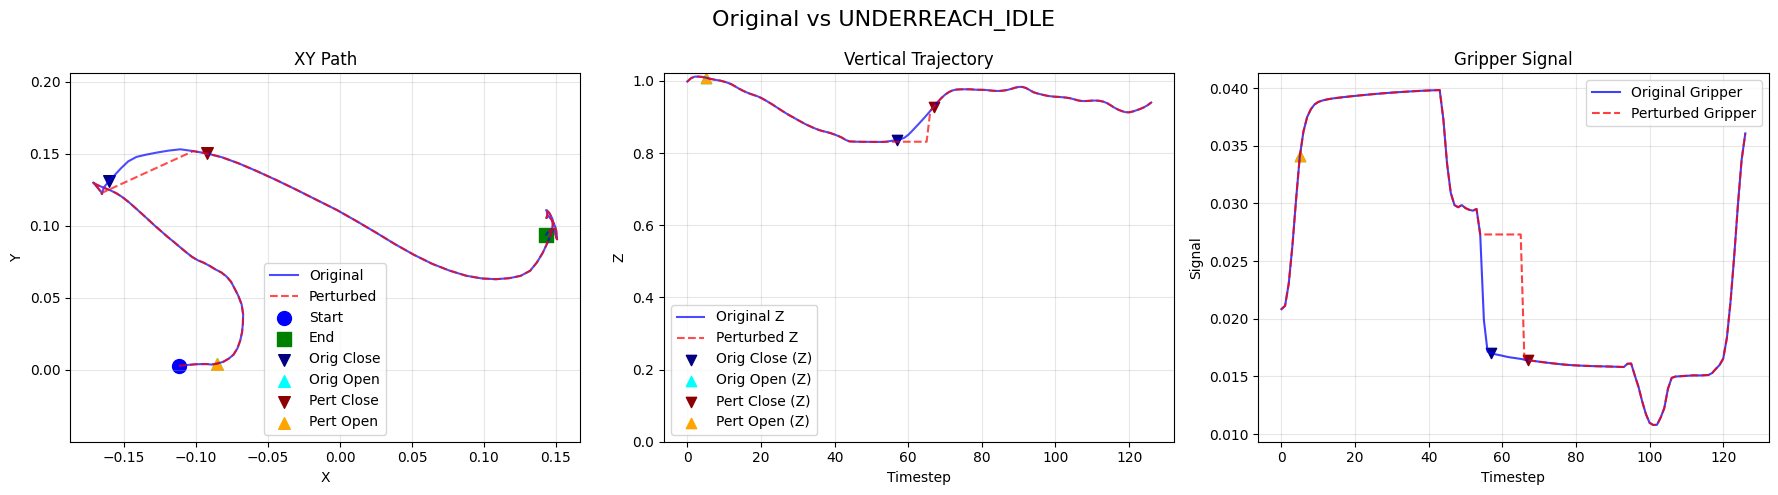

Visualizing 3D Plot for: PREMATURE_CLOSE


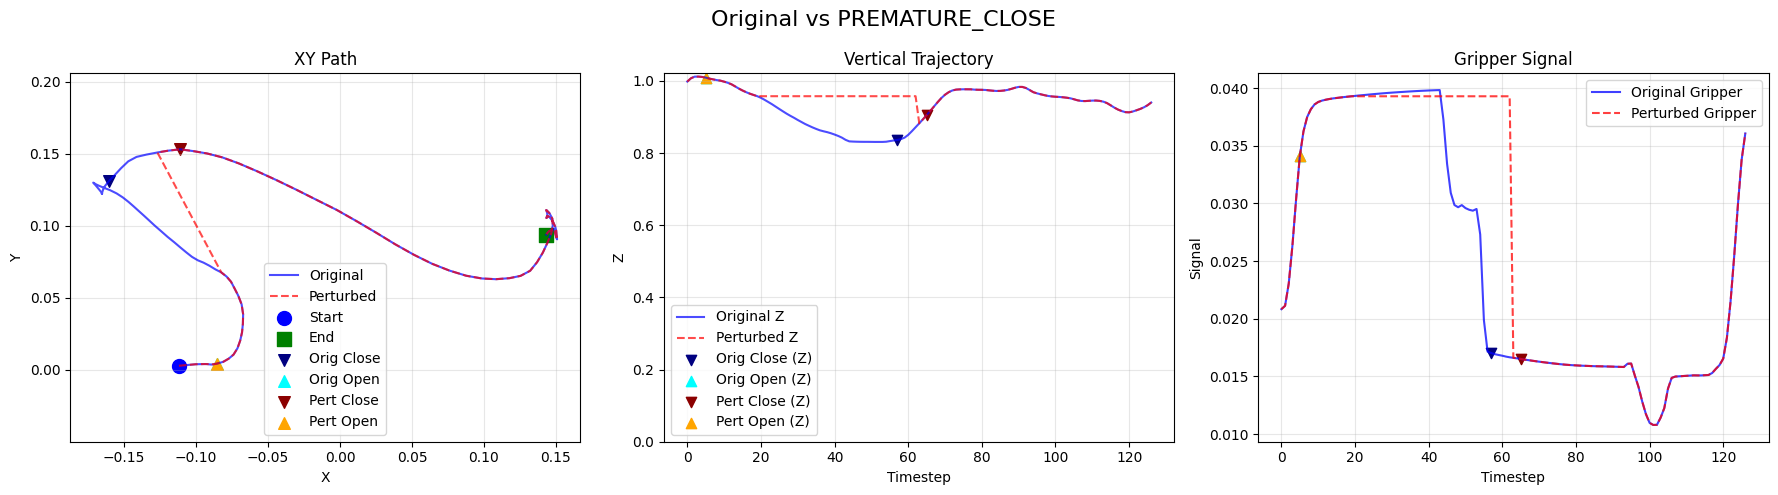

Visualizing 3D Plot for: LATERAL_DRIFT


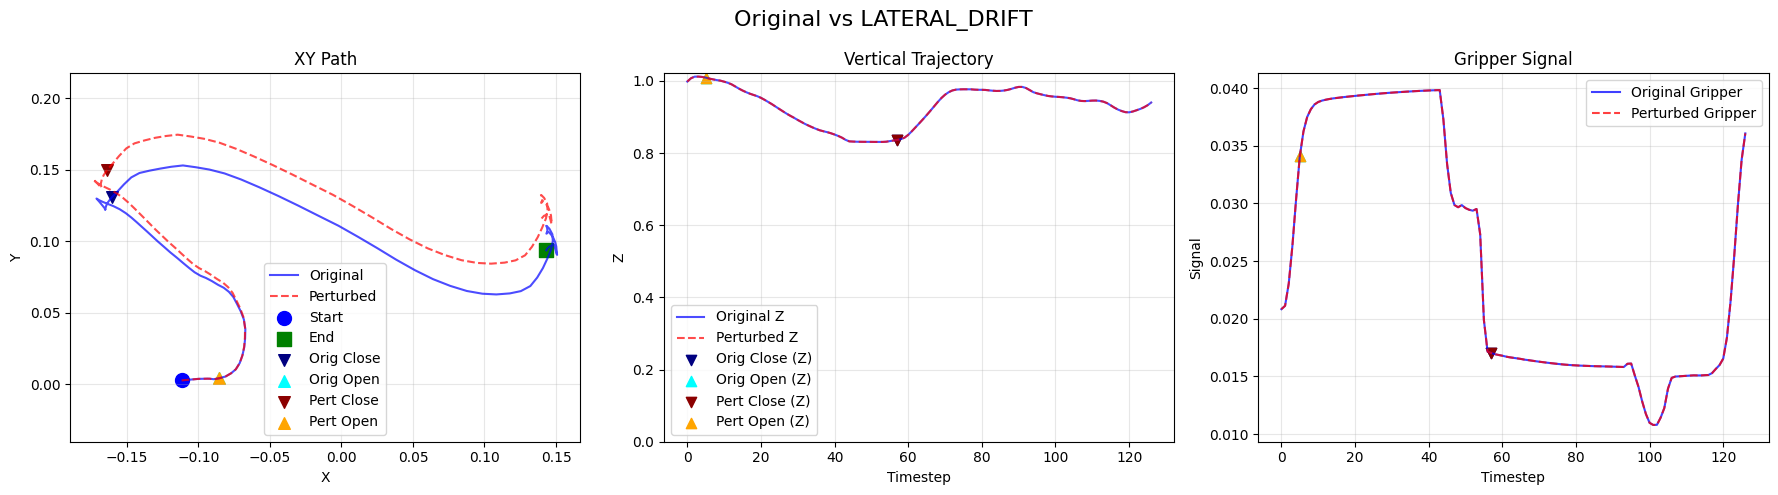

Visualizing 3D Plot for: PREMATURE_OPEN


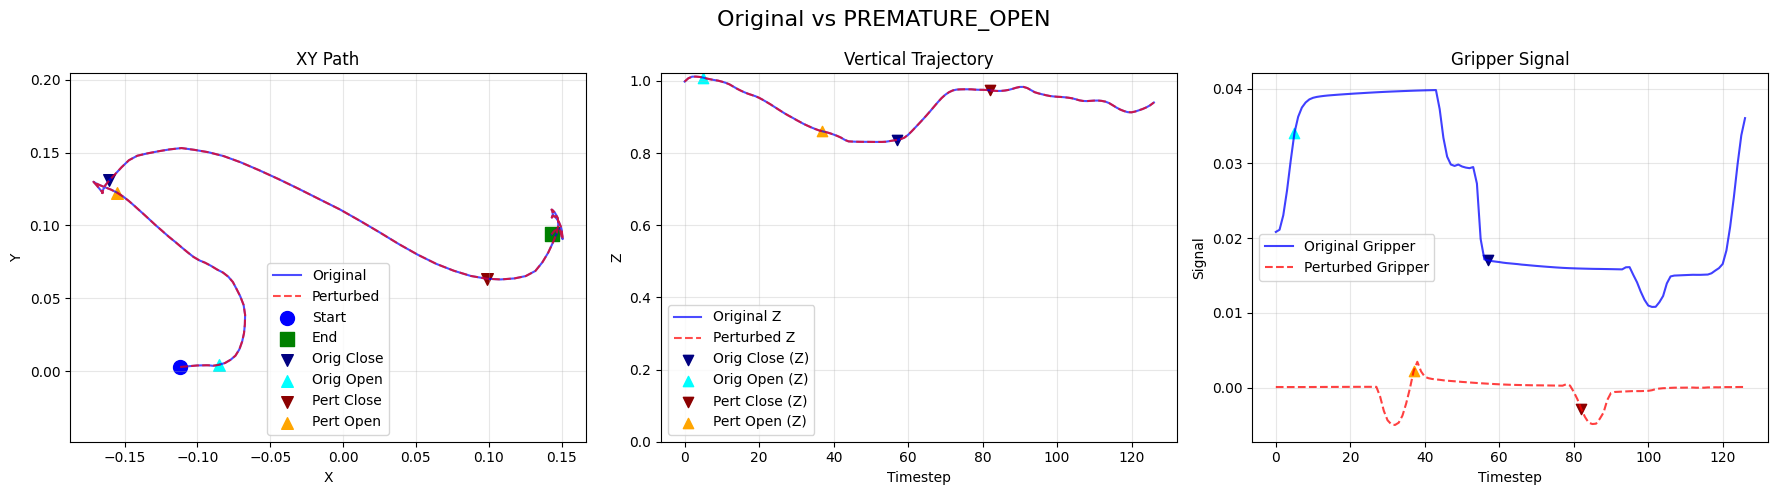

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)



--- Generating Simulation Videos ---
Rendering Original Trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []


[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


Created environment with name NutAssemblySquare
Action size is 7
Rendering UNDERREACH_IDLE Trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Rendering Recovery for UNDERREACH_IDLE...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Rendering PREMATURE_CLOSE Trajectory...

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos']
using obs modality: rgb with keys: []
Created environment with name NutAssemblySquare
Action size is 7
Rendering Recovery for PREMATURE_CLOSE...

============= Initialized Observation Utils with Obs Spec =======


Visualization Generation Complete!


In [7]:
import matplotlib.pyplot as plt
from a2l_pr.utils.visualization import visualize_trajectory_comparison
from IPython.display import HTML, display
from base64 import b64encode
from pathlib import Path
import imageio

try:
    import robomimic.utils.obs_utils as ObsUtils
    import robomimic.utils.env_utils as EnvUtils
    import robomimic.utils.file_utils as FileUtils
    HAS_ROBOMIMIC = True
except ImportError:
    print("robomimic not found in environment, video rendering will be skipped.")
    HAS_ROBOMIMIC = False

# 5.1 Plot Visualizations
print("\n--- Generating Plots ---")
generator = PerturbationGenerator()

# Re-generate to get full trajectory dictionaries
results_for_vis = {}
for p_type in perturbation_types:
    res = generator.apply_perturbation(trajectory, p_type, severity=0.5, seed=42)
    if res is not None:
        results_for_vis[p_type.name] = res

# Display 3D plots
for name, res in results_for_vis.items():
    print(f"Visualizing 3D Plot for: {name}")
    try:
        visualize_trajectory_comparison(
            trajectory, 
            res.perturbed_trajectory, 
            title=f"Original vs {name}"
        )
    except Exception as e:
        print(f"Plot failed: {e}")

# 5.2 Simulation Video Visualizations
if HAS_ROBOMIMIC:
    print("\n--- Generating Simulation Videos ---")

    def render_trajectory_to_video(traj_dict, dataset_path, ep_name, output_path):
        if not os.path.exists(dataset_path):
            return False
        try:
            dummy_spec = dict(obs=dict(low_dim=["robot0_eef_pos"], rgb=[]))
            ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)
            env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
            env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render=False, render_offscreen=True)
            
            with h5py.File(dataset_path, 'r') as f:
                states = f[ep_name]['states'][()]
                initial_state = dict(states=states[0])
                if EnvUtils.is_robosuite_env(env_meta):
                    initial_state["model"] = f[ep_name].attrs["model_file"]
                    
            env.reset_to(initial_state)
            actions = traj_dict.get('actions', [])
            
            writer = imageio.get_writer(output_path, fps=20)
            for i in range(len(actions)):
                env.step(actions[i])
                if i % 5 == 0:
                    frame = env.render(mode="rgb_array", height=256, width=256, camera_name="agentview")
                    writer.append_data(frame)
            writer.close()
            return True
        except Exception as e:
            print(f"Render failed: {e}")
            return False

    OUTPUT_DIR = Path(os.getcwd()) / "output"
    OUTPUT_DIR.mkdir(exist_ok=True)

    ep_name = 'data/demo_0'
    html_content = "<div style='display: flex; flex-direction: row; flex-wrap: wrap; justify-content: space-around;'>"

    # Render Original
    orig_out = str(OUTPUT_DIR / 'learning_demo_original.mp4')
    print("Rendering Original Trajectory...")
    if render_trajectory_to_video(trajectory, robomimic_hdf5_path, ep_name, orig_out):
        orig_b64 = b64encode(open(orig_out, "rb").read()).decode('ascii')
        html_content += f"""
        <div style='text-align: center; margin-bottom: 20px;'>
            <h3>No Failure (Original)</h3>
            <video width='350' controls autoplay loop>
                <source src='data:video/mp4;base64,{orig_b64}' type='video/mp4'>
            </video>
        </div>
        """

    # Render Perturbed and Recovered
    for name, res in results_for_vis.items():
        print(f"Rendering {name} Trajectory...")
        pert_out = str(OUTPUT_DIR / f'learning_demo_{name}.mp4')
        if render_trajectory_to_video(res.perturbed_trajectory, robomimic_hdf5_path, ep_name, pert_out):
            pert_b64 = b64encode(open(pert_out, "rb").read()).decode('ascii')
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px;'>
                <h3>Failure: {name}</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{pert_b64}' type='video/mp4'>
                </video>
            </div>
            """

        # Predict recovery and simulate it
        print(f"Rendering Recovery for {name}...")
        rec_out = str(OUTPUT_DIR / f'learning_demo_recovery_{name}.mp4')
        
        # We use extract_learning_sample to format it for the model
        sample = extract_learning_sample(res.perturbed_trajectory, failure_type_id=0)
        # Reshape frames from (N, C, H, W) to (N*C, H, W)
        frames_np = sample['frames']
        N, C, H, W = frames_np.shape
        frames_np = frames_np.reshape((N * C, H, W))
        frames = torch.tensor(frames_np).unsqueeze(0).to(device)
        actions_tensor = torch.tensor(sample['actions']).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(frames, actions_tensor)
            pred_rec_params = outputs['recovery_params'][0].cpu().numpy()
            pred_failure_idx = torch.argmax(outputs['failure_logits'], dim=1).item()
            
        # If model thinks it's a failure, simulate the recovery steps
        # We append 20 steps of the predicted residual action
        recovered_actions = list(res.perturbed_trajectory.get('actions', []))
        if pred_failure_idx != 0:
            for _ in range(20):
                recovered_actions.append(pred_rec_params)
        
        recovered_traj_dict = {'actions': recovered_actions}
        
        if render_trajectory_to_video(recovered_traj_dict, robomimic_hdf5_path, ep_name, rec_out):
            rec_b64 = b64encode(open(rec_out, "rb").read()).decode('ascii')
            html_content += f"""
            <div style='text-align: center; margin-bottom: 20px; border: 2px solid green;'>
                <h3>Recovery: {name}</h3>
                <video width='350' controls autoplay loop>
                    <source src='data:video/mp4;base64,{rec_b64}' type='video/mp4'>
                </video>
            </div>
            """

    html_content += "</div>"
    display(HTML(html_content))
    print("\nVisualization Generation Complete!")